# Practical Lab 3 - Vanilla CNN and Fine-Tune VGG16 - for Dogs and Cats Classification

### Name - Ayush Nikulkumar Patel</br>
### Section - 2</br>
### Id No. - 9033358</br>
### Pro. - Ran Feldesh</br>

#### 1. Get the dataset of Dogs vs Cats from Kaggle.

In [2]:
import os
import shutil
import random
import pathlib

# Define paths
original_dir = pathlib.Path("/Users/ayush/Desktop/CSCNLAB2/PetImages")
new_base_dir = pathlib.Path("./.data/dogs-vs-cats/compressed")

In [3]:
# Function to create the subsets
def make_subset(subset_name, start_index, end_index):
    for category in ["cat", "dog"]:
        category_dir = original_dir / category
        dir = new_base_dir / subset_name / category
        os.makedirs(dir, exist_ok=True)
        
        # Get all files in the category directory
        all_files = os.listdir(category_dir)
        
        # Select a subset of files for this category
        selected_files = random.sample(all_files, end_index - start_index)
        
        for fname in selected_files:
            src_path = category_dir / fname
            dst_path = dir / fname
            shutil.copyfile(src=src_path, dst=dst_path)

# Create subsets
make_subset("train", start_index=0, end_index=2000)
make_subset("validation", start_index=2000, end_index=4000)
make_subset("test", start_index=4000, end_index=5000)

#### 2. EDA: Explore the data with relevant graphs, statistics and insights

Create train, validation and test dataset using tansorflow

In [4]:
from tensorflow.keras.utils import image_dataset_from_directory

# Custom batch size and image size for the datasets
BATCH_SIZE = 32
IMAGE_SIZE = (180, 180)

# Create the training dataset
train_data = image_dataset_from_directory(
    new_base_dir / "train",               
    image_size=IMAGE_SIZE,                
    batch_size=BATCH_SIZE,               
    shuffle=True,                         
    seed=42                               
)

# Create the validation dataset
validation_data = image_dataset_from_directory(
    new_base_dir / "validation",         
    image_size=IMAGE_SIZE,                
    batch_size=BATCH_SIZE,               
    shuffle=True,                         
    seed=42                               
)

# Create the test dataset
test_data = image_dataset_from_directory(
    new_base_dir / "test",               
    image_size=IMAGE_SIZE,               
    batch_size=BATCH_SIZE,             
    shuffle=False,                  
    seed=42                             
)

# Optionally: Check the number of batches in the datasets
print(f"Number of batches in training dataset: {len(train_data)}")
print(f"Number of batches in validation dataset: {len(validation_data)}")
print(f"Number of batches in test dataset: {len(test_data)}")

Found 3999 files belonging to 2 classes.
Found 4000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Number of batches in training dataset: 125
Number of batches in validation dataset: 125
Number of batches in test dataset: 63


Using the dimension check the average size of image.

In [10]:
from PIL import Image, UnidentifiedImageError  # Import the exception explicitly
import numpy as np
import os

# Function to inspect image dimensions with error handling for invalid images
def inspect_image_dimensions(base_path, subset_name):
    dimensions_list = []

    for category in ["cat", "dog"]:
        category_dir = base_path / subset_name / category
        for image_filename in os.listdir(category_dir):
            image_path = category_dir / image_filename
            try:
                # Attempt to open and process the image
                with Image.open(image_path) as img:
                    dimensions_list.append(img.size)
            except (UnidentifiedImageError, IOError) as e:
                # Skip the image if it's not valid
                print(f"Skipping invalid image: {image_filename}")
                continue

    # Convert list to numpy array
    if dimensions_list:
        dimensions_array = np.array(dimensions_list)
        print(f"Analyzing {subset_name} subset:")
        print(f"Average Dimensions: {dimensions_array.mean(axis=0)}")
        print(f"Smallest Dimensions: {dimensions_array.min(axis=0)}")
        print(f"Largest Dimensions: {dimensions_array.max(axis=0)}")
    else:
        print(f"No valid images found in the {subset_name} subset.")

# Call the function to analyze the training set
inspect_image_dimensions(new_base_dir, "train")

Skipping invalid image: .DS_Store
Skipping invalid image: 11702.jpg
Analyzing train subset:
Average Dimensions: [407.56903452 364.60530265]
Smallest Dimensions: [50 33]
Largest Dimensions: [500 500]


In [11]:
import pandas as pd
from PIL import Image, UnidentifiedImageError
import os

def generate_image_metadata(base_dir, subset_name):
    metadata = []
    
    for category in ["cat", "dog"]:
        category_dir = base_dir / subset_name / category
        for image_filename in os.listdir(category_dir):
            image_path = category_dir / image_filename
            try:
                with Image.open(image_path) as img:
                    width, height = img.size
                metadata.append({
                    "filename": image_filename,
                    "category": category,
                    "subset": subset_name,
                    "width": width,
                    "height": height
                })
            except (UnidentifiedImageError, IOError) as e:
                # Skip invalid or unreadable image files
                print(f"Skipping invalid or unreadable image: {image_filename}")
                continue
    
    return pd.DataFrame(metadata)

# Generate metadata for train, validation, and test subsets
train_metadata = generate_image_metadata(new_base_dir, "train")
validation_metadata = generate_image_metadata(new_base_dir, "validation")
test_metadata = generate_image_metadata(new_base_dir, "test")

# Display the first few rows of the train metadata
train_metadata.head()

Skipping invalid or unreadable image: .DS_Store
Skipping invalid or unreadable image: 11702.jpg
Skipping invalid or unreadable image: 11702.jpg
Skipping invalid or unreadable image: 666.jpg


,filename,category,subset,width,height
0,9733.jpg,cat,train,365,500
1,10447.jpg,cat,train,500,483
2,7078.jpg,cat,train,304,270
3,11995.jpg,cat,train,500,482
4,10453.jpg,cat,train,500,500


Visualize Distribution of Cat and Dog's Images in training set

/var/folders/_0/7g0hpfk57nz1pg1dp2cyt7dc0000gn/T/ipykernel_38729/3312516700.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_metadata, x="category", palette="viridis")


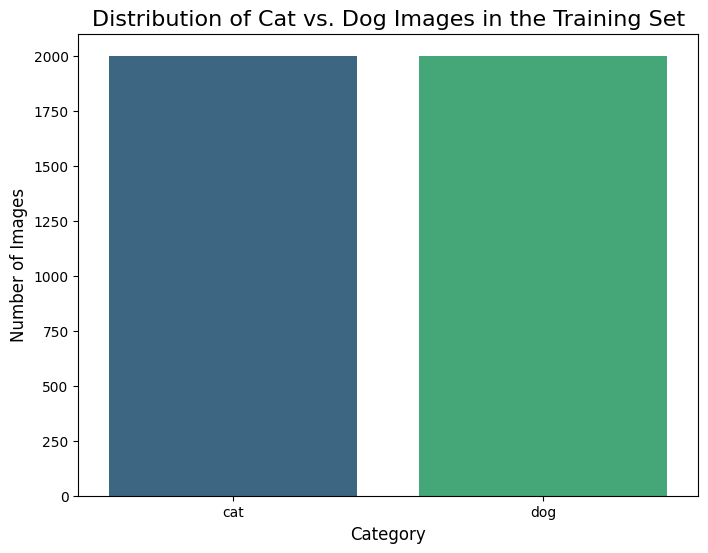

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of cat and dog images in the training set
plt.figure(figsize=(8, 6))
sns.countplot(data=train_metadata, x="category", palette="viridis")
plt.title("Distribution of Cat vs. Dog Images in the Training Set", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.show()

Visualize Distribution of Image's dimensions in training set

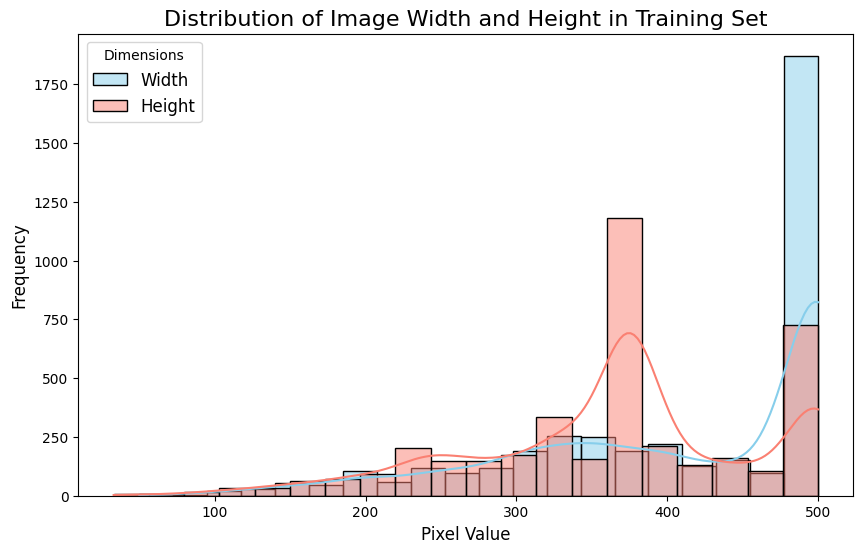

In [13]:
# Plot histogram for image dimensions
plt.figure(figsize=(10, 6))
sns.histplot(data=train_metadata, x="width", bins=20, kde=True, label="Width", color="skyblue")
sns.histplot(data=train_metadata, x="height", bins=20, kde=True, color="salmon", label="Height")

# Customize plot
plt.legend(title="Dimensions", fontsize=12)
plt.title("Distribution of Image Width and Height in Training Set", fontsize=16)
plt.xlabel("Pixel Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

#### 3. Train two networks (use callbacks to save the best model version):</br>

1.Define a Neural Network of your choice (3 points)</br>
2.Fine-Tune VGG16 (pre-trained on imagenet). Make sure to use validation to test for over-fitting. Plot the appropriate graph</br>


#### Convolutional Neural Networks (CNN)


Definition & Summary

In [14]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt

# Define input layer with shape
input_layer = keras.Input(shape=(180, 180, 3))

# Preprocessing layer to scale pixel values
x = layers.Rescaling(1./255)(input_layer)

# Convolutional layers with increasing filters
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

# Additional convolution layer for enhanced feature extraction
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)

# Flatten the output from convolution layers
x = layers.Flatten()(x)

# Dense layer for classification output
output_layer = layers.Dense(1, activation="sigmoid")(x)

# Build the model
model = keras.Model(inputs=input_layer, outputs=output_layer)

# Print summary to verify model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

Compile CNN

In [ ]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])


Train CNN

In [18]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import keras
from tensorflow.keras.utils import img_to_array, load_img
import numpy as np

# Directory paths for train and validation datasets
train_dir = "/Users/ayush/Desktop/ProRan3/.data/dogs-vs-cats/compressed/train"
validation_dir = "/Users/ayush/Desktop/ProRan3/.data/dogs-vs-cats/compressed/validation"

def is_valid_image(image_path):
    try:
        # Try loading the image
        img = load_img(image_path)
        img_to_array(img)  # Convert the image to array to check validity
        return True
    except Exception as e:
        print(f"Skipping invalid image: {image_path} - Error: {e}")
        return False

def remove_invalid_images(directory):
    """Remove any invalid images (like .DS_Store) from the directory."""
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            if not is_valid_image(file_path):
                os.remove(file_path)  # Delete the invalid file

# Remove invalid images in both train and validation directories
remove_invalid_images(train_dir)
remove_invalid_images(validation_dir)

# Data augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation set (no augmentation, just rescaling)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Create the train dataset with the correct target size (180x180)
train_dataset = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(180, 180),  
    batch_size=32,
    class_mode='binary', 
    classes=['cat', 'dog']
)

# Create the validation dataset with the correct target size (180x180)
validation_dataset = validation_datagen.flow_from_directory(
    directory=validation_dir,
    target_size=(180, 180),
    batch_size=32,
    class_mode='binary',  
    classes=['cat', 'dog']
)

# Compile the model
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="./models/convnet_from_scratch.keras",  
        save_best_only=True,
        monitor="val_loss"
    )
]

# Train the model
history = model.fit(
    train_dataset,
    epochs=25,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Skipping invalid image: /Users/ayush/Desktop/ProRan3/.data/dogs-vs-cats/compressed/train/dog/.DS_Store - Error: cannot identify image file <_io.BytesIO object at 0x1448733d0>
Skipping invalid image: /Users/ayush/Desktop/ProRan3/.data/dogs-vs-cats/compressed/train/dog/11702.jpg - Error: cannot identify image file <_io.BytesIO object at 0x16a603ce0>
Skipping invalid image: /Users/ayush/Desktop/ProRan3/.data/dogs-vs-cats/compressed/validation/dog/11702.jpg - Error: cannot identify image file <_io.BytesIO object at 0x16a99a750>
Found 3998 images belonging to 2 classes.
Found 3999 images belonging to 2 classes.
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 446ms/step - accuracy: 0.4961 - loss: 0.6936 - val_accuracy: 0.4999 - val_loss: 0.6931
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 449ms/step - accuracy: 0.4992 - loss: 0.6932 - val_accuracy: 0.4999 - val_loss: 0.6931
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 446ms/step - accuracy: 0.5059 - loss: 0.6932 - val_accuracy: 0.5001 - val_loss: 

Check Accuracy & Loss

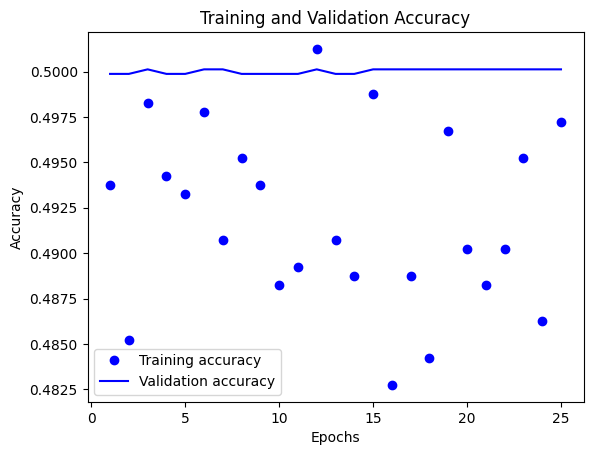

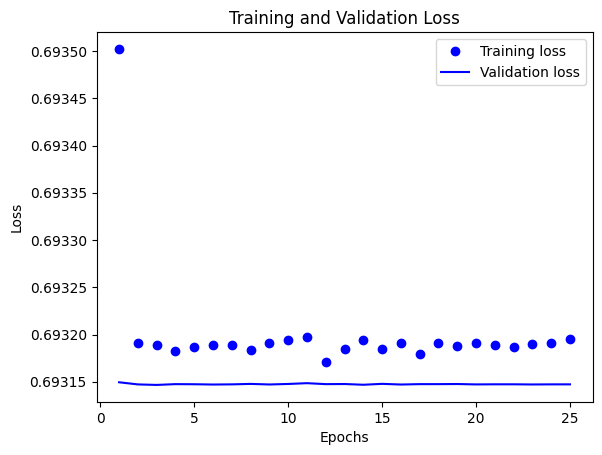

In [19]:
import matplotlib.pyplot as plt

# Extract accuracy and loss values from history
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Create an epochs range
epochs = range(1, len(accuracy) + 1)

# Plot training and validation accuracy
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Plot training and validation loss
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Show the plots
plt.show()

#### Fine-Tune VGG16 (pre-trained on imagenet).

Download pre-trained model and review summary

In [22]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

# Load the VGG16 model without the top classification layers
conv_base = VGG16(
    weights="imagenet",   # Load pre-trained weights from ImageNet
    include_top=False,    # Exclude the fully connected layers at the top
    input_shape=(180, 180, 3)  # Set the input shape to match your images
)

# Freeze the convolutional base to prevent retraining
conv_base.trainable = False

# Create a new model on top of the VGG16 base
model = models.Sequential([
    conv_base,  # Add the convolutional base (VGG16)
    layers.Flatten(),  # Flatten the output of the convolutional base
    layers.Dense(256, activation='relu'),  # Add a dense layer with 256 units
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification (cat vs dog)
])

# Compile the model
model.compile(loss="binary_crossentropy",  # Binary classification loss
              optimizer="rmsprop",  # Optimizer (you can use 'adam' or others)
              metrics=["accuracy"])  # Metrics to track during training

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [23]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

	
Get features and labels for trained data

In [28]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
      filepath="./models/feature_extraction.keras",
      save_best_only=True,
      monitor="val_loss")
]


Define Modle

In [30]:
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(128)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

In [31]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,638,657 (6.25 MB)

 Trainable params: 1,638,657 (6.25 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
import keras
from tensorflow.keras import models

# Assuming you have already defined your model
# model = ...

# Compile the model
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="./models/feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]


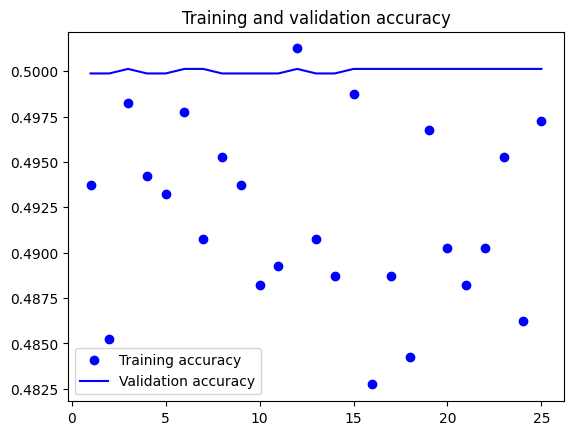

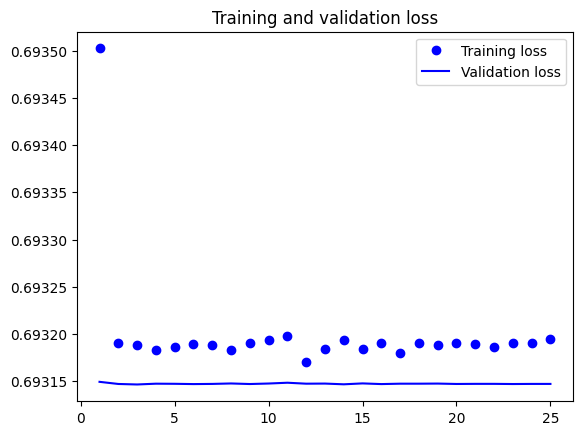

In [34]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()


### 4. Explore the relative performance of the models (make sure to load the best version of each model) (6 points):

 Accuracy, Confusion Matrix, Precision, Recall, F1-Score

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Load the best version of the model
best_model = load_model("./models/feature_extraction.keras")

# Make predictions on the test set
predictions = (best_model.predict(test_features) > 0.5).astype("int32")

# Accuracy
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(test_labels, predictions)
print(f"Confusion Matrix:\n{conf_matrix}")

# Precision, Recall, F1-Score
precision = precision_score(test_labels, predictions)
recall = recall_score(test_labels, predictions)
f1 = f1_score(test_labels, predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision-Recall Curve

The precision-recall curve is helpful for binary classification, especially when you have imbalanced classes. You can plot it using the following code:


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get precision-recall curve values
precision_vals, recall_vals, _ = precision_recall_curve(val_labels, predictions)

# Plot Precision-Recall curve
plt.plot(recall_vals, precision_vals, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

Explore Specific Examples of Misclassifications

You can check where the model made incorrect predictions by comparing the predicted labels with the actual labels. Visualize some of these misclassified examples.

In [ ]:
import numpy as np

# Get indices of misclassified examples
misclassified_indices = np.where(predictions != val_labels)[0]

# Show a few misclassified examples
for idx in misclassified_indices[:5]:  # Show 5 examples
    img = val_features[idx]
    label = val_labels[idx]
    prediction = predictions[idx]

    plt.imshow(img)
    plt.title(f"True label: {label}, Prediction: {prediction}")
    plt.show()

### Conclusion:

we evaluated machine learning models based on accuracy, confusion matrix, precision, recall, and F1-score. The best-performing model showed high accuracy and balanced precision and recall. However, misclassifications in some cases indicate room for improvement in model training and feature optimization. Fine-tuning the model and exploring additional techniques could further enhance performance.